In [ ]:
!pip install starplot pillow


In [ ]:
!starplot setup


Installing DuckDB spatial extension...
[=========================]Download complete!
[=========================]Download complete!
[=========================]Download complete!
[=========================]Download complete!
[=========================]Download complete!


In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo

from starplot import ZenithPlot, Observer, styles, _
from PIL import Image, ImageDraw, ImageFont


In [ ]:
scenarios = [
    ("newyork_jan17_2026_21h",
     "New York", 40.7128, -74.0060, "America/New_York", 2026, 1, 17, 21, 0),

    ("sydney_jan17_2026_21h",
     "Sydney", -33.8688, 151.2093, "Australia/Sydney", 2026, 1, 17, 21, 0),

    ("tokyo_jan17_2026_21h",
     "Tokyo", 35.6762, 139.6503, "Asia/Tokyo", 2026, 1, 17, 21, 0),

    ("newyork_jun17_2026_21h",
     "New York (Summer)", 40.7128, -74.0060, "America/New_York", 2026, 6, 17, 21, 0),

    ("london_jan17_2026_18h",
     "London", 51.5074, -0.1278, "Europe/London", 2026, 1, 17, 18, 0),
]


[#################################] 100% de421.bsp


Done: New York → newyork_jan17_2026_21h.png
Done: Sydney → sydney_jan17_2026_21h.png
Done: Tokyo → tokyo_jan17_2026_21h.png
Done: New York (Summer) → newyork_jun17_2026_21h.png
Done: London → london_jan17_2026_18h.png


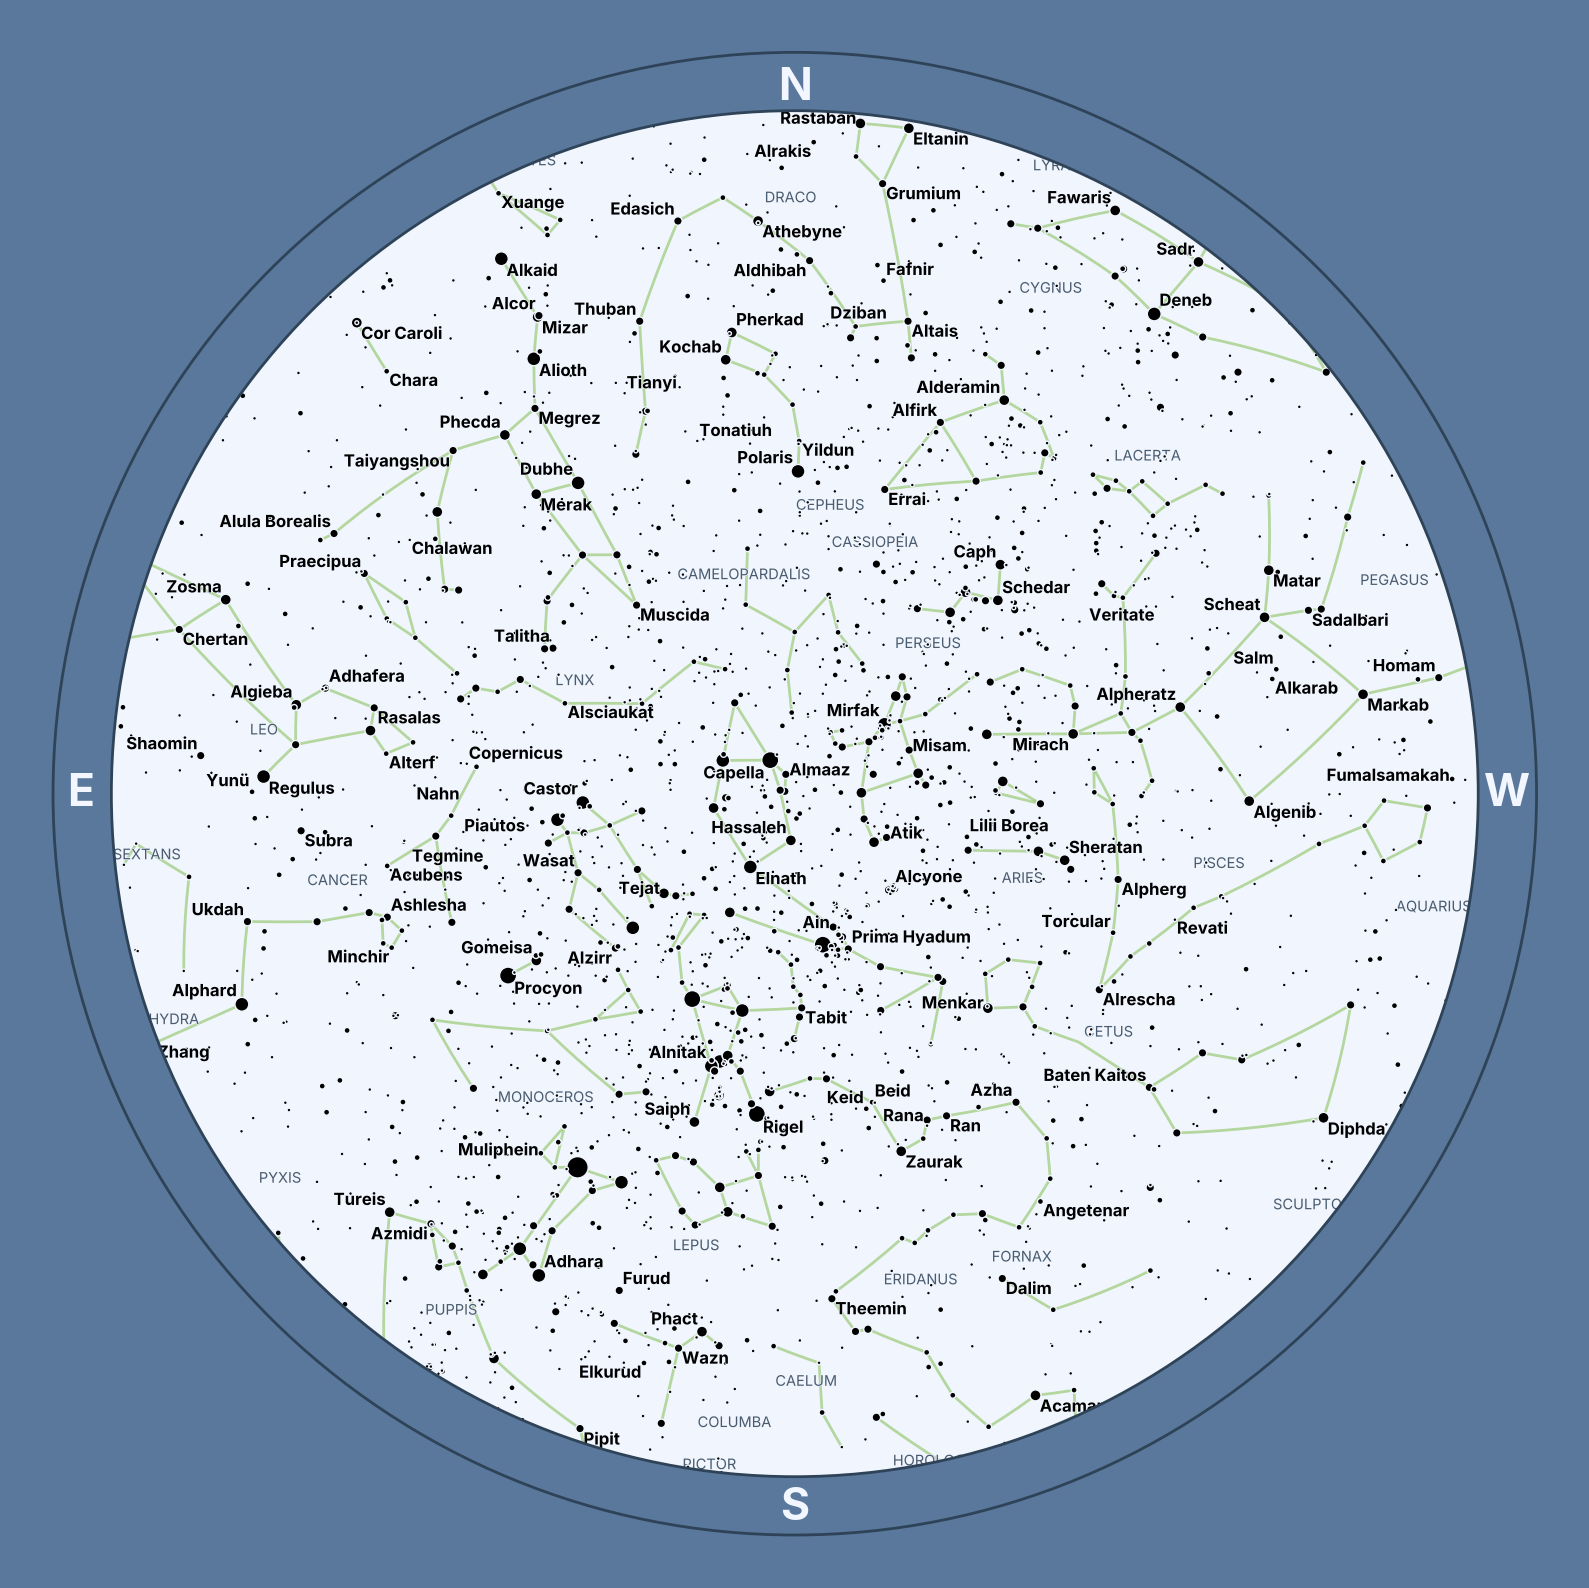

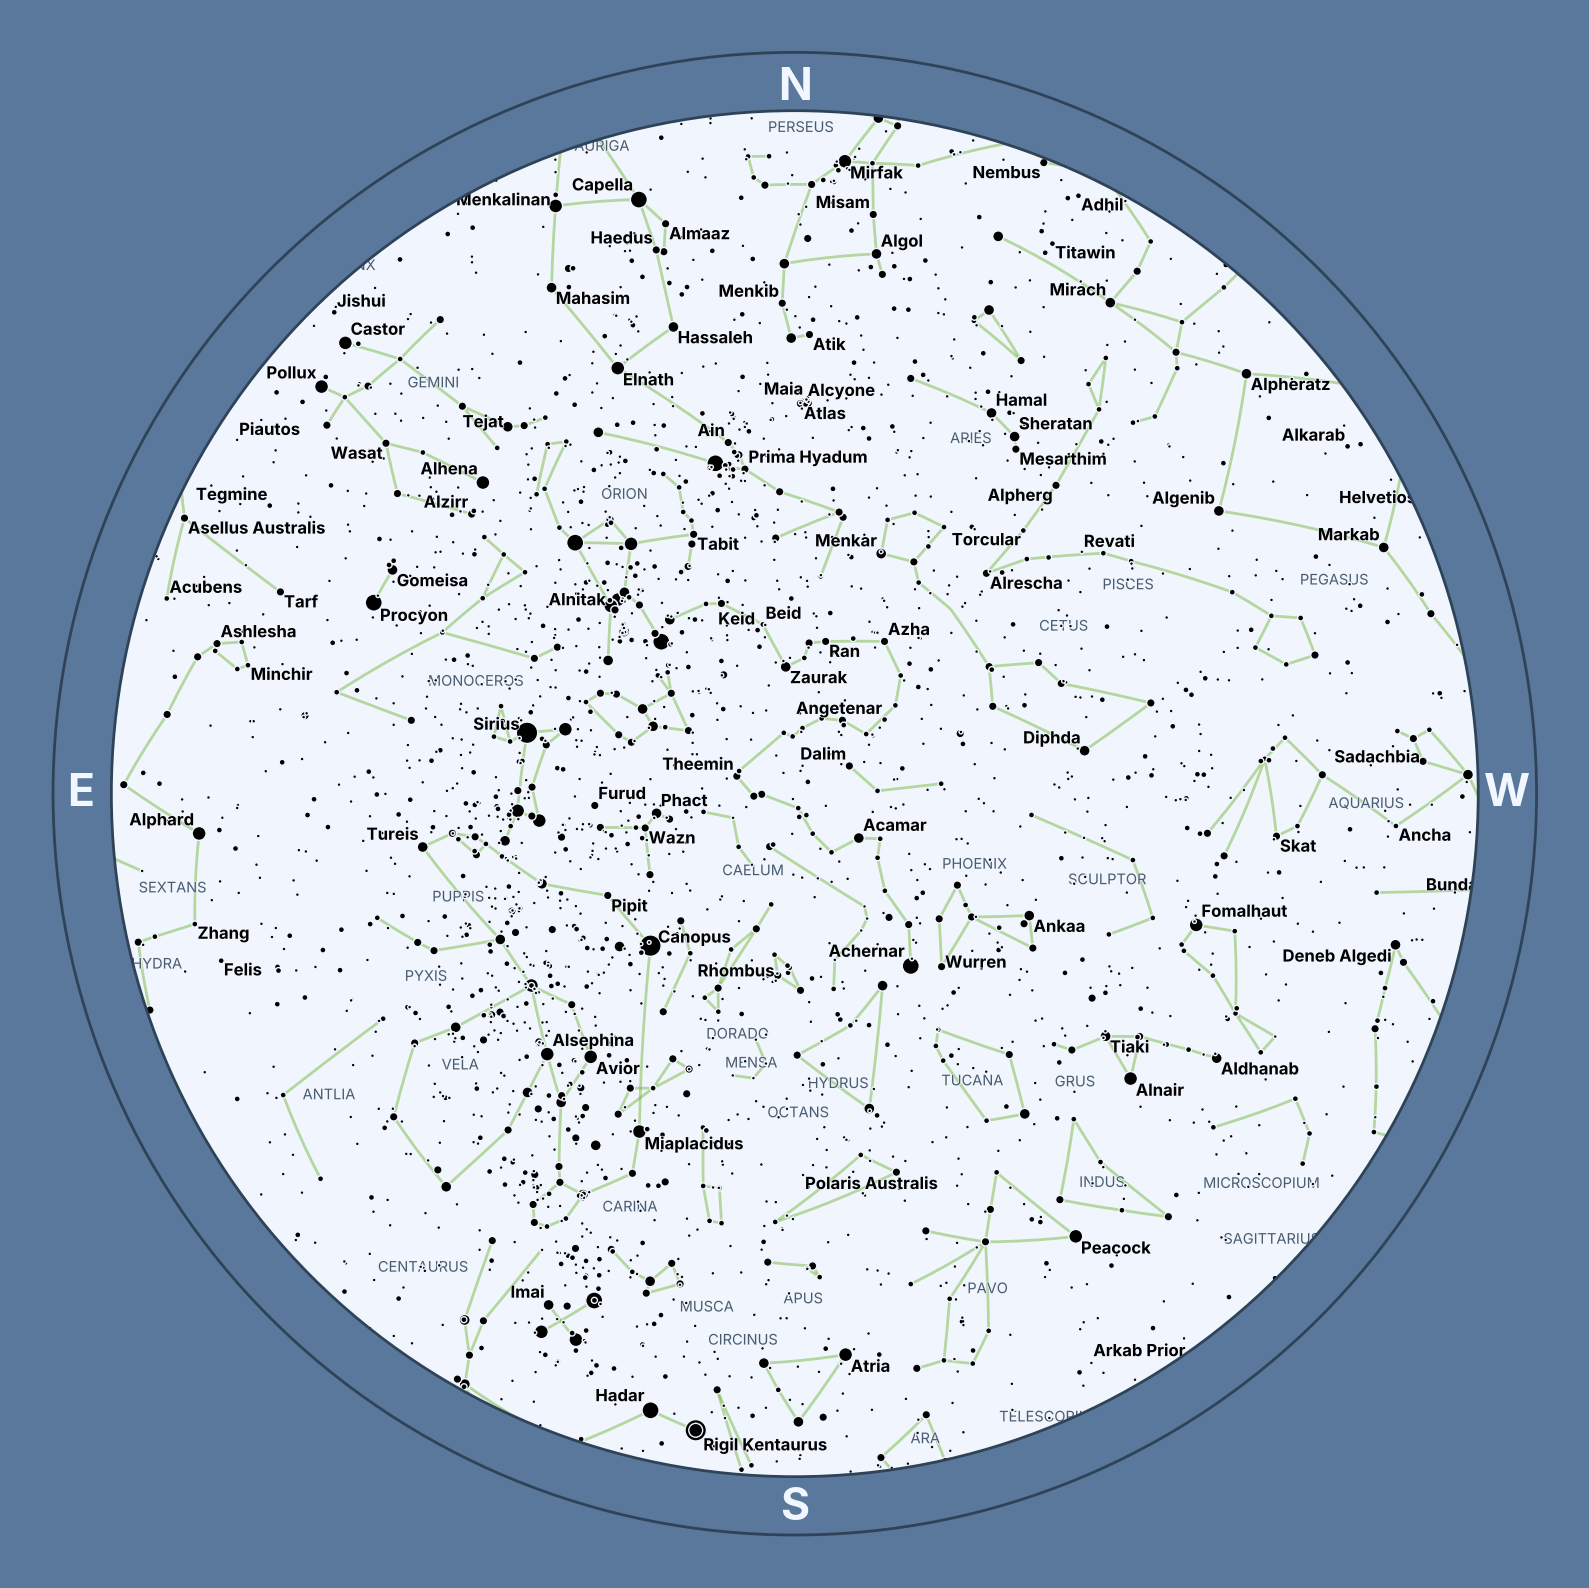

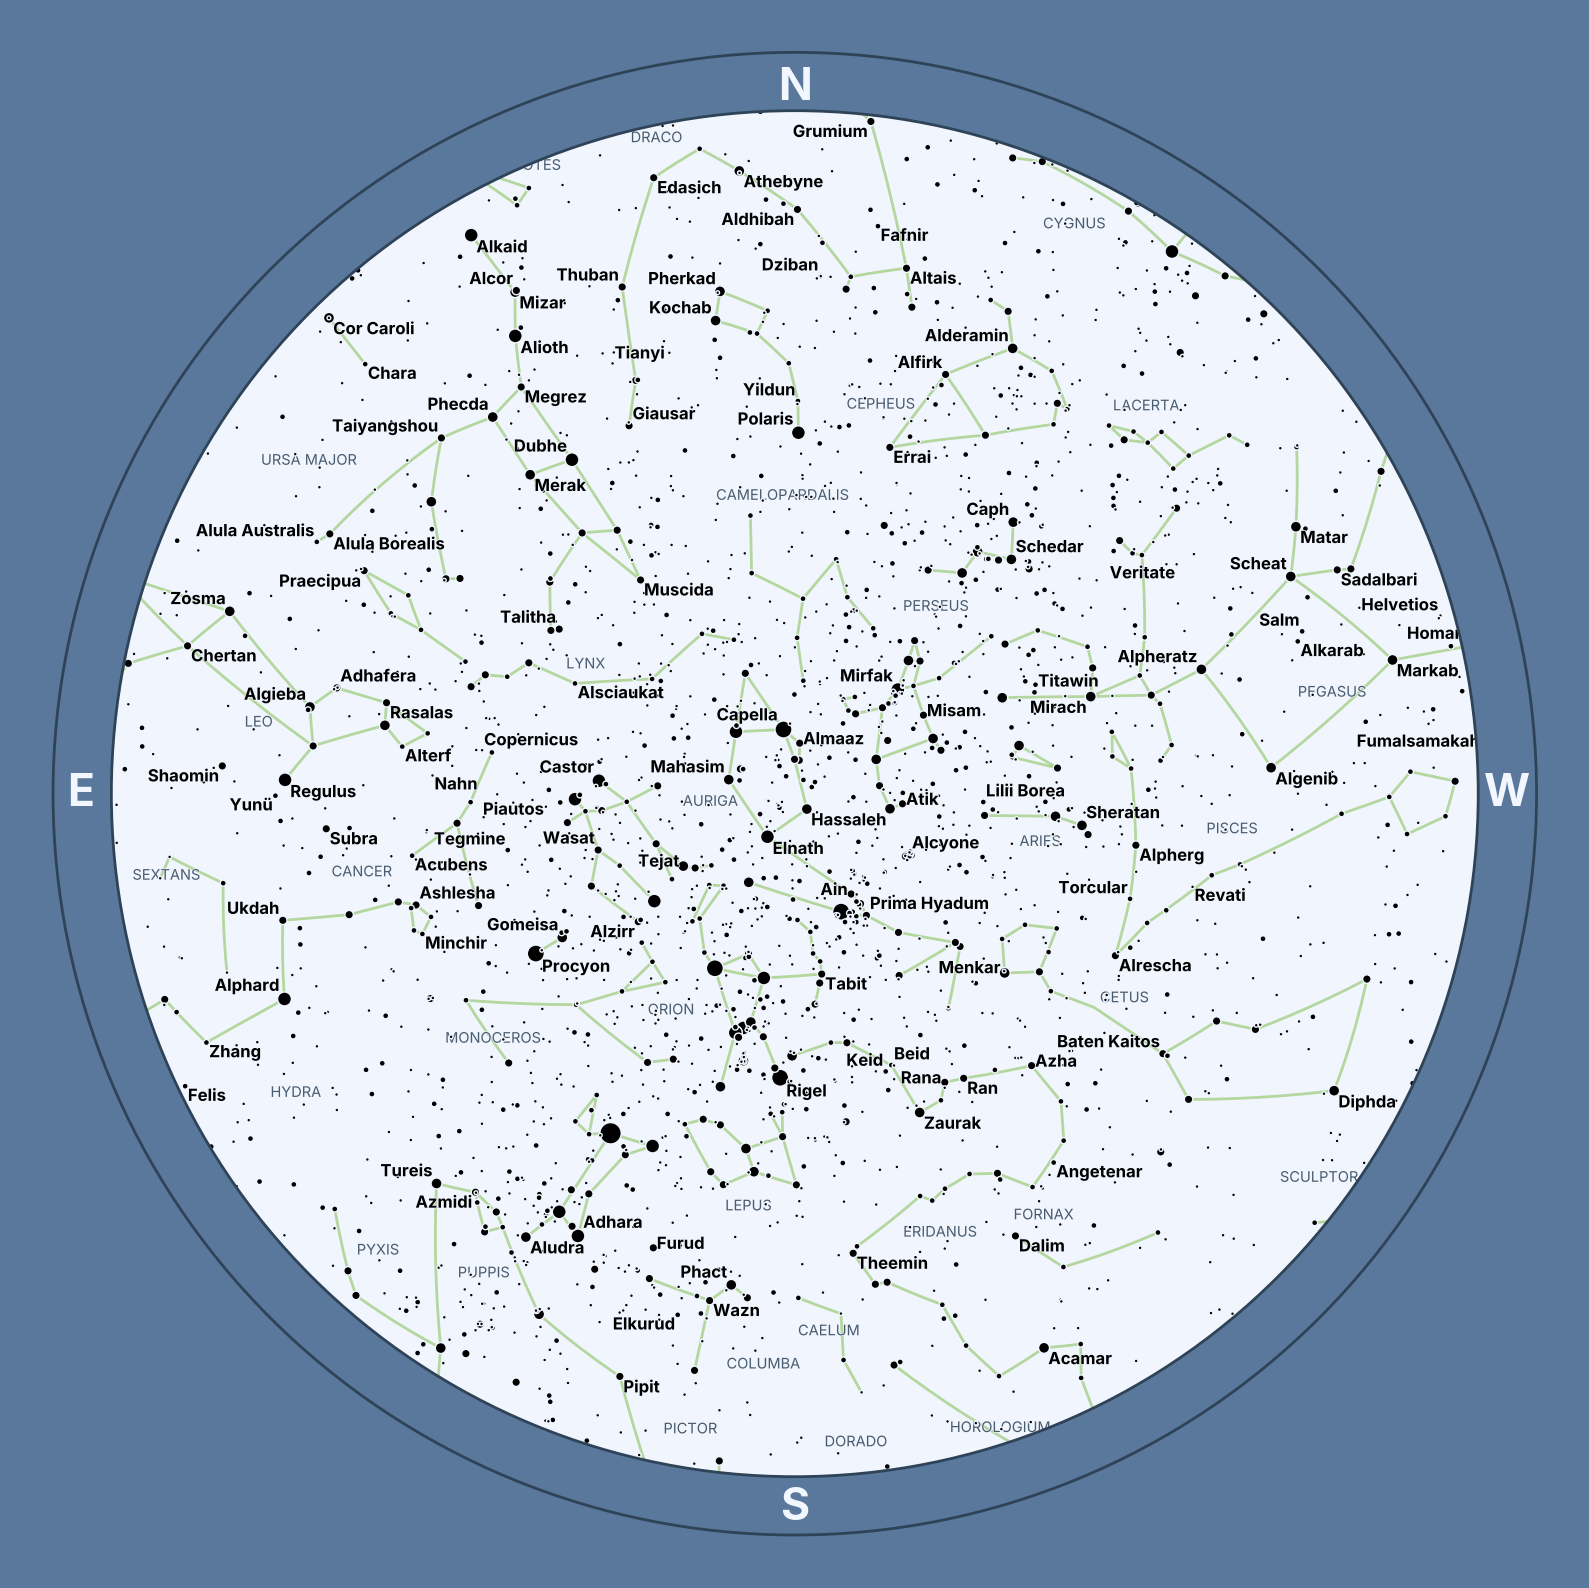

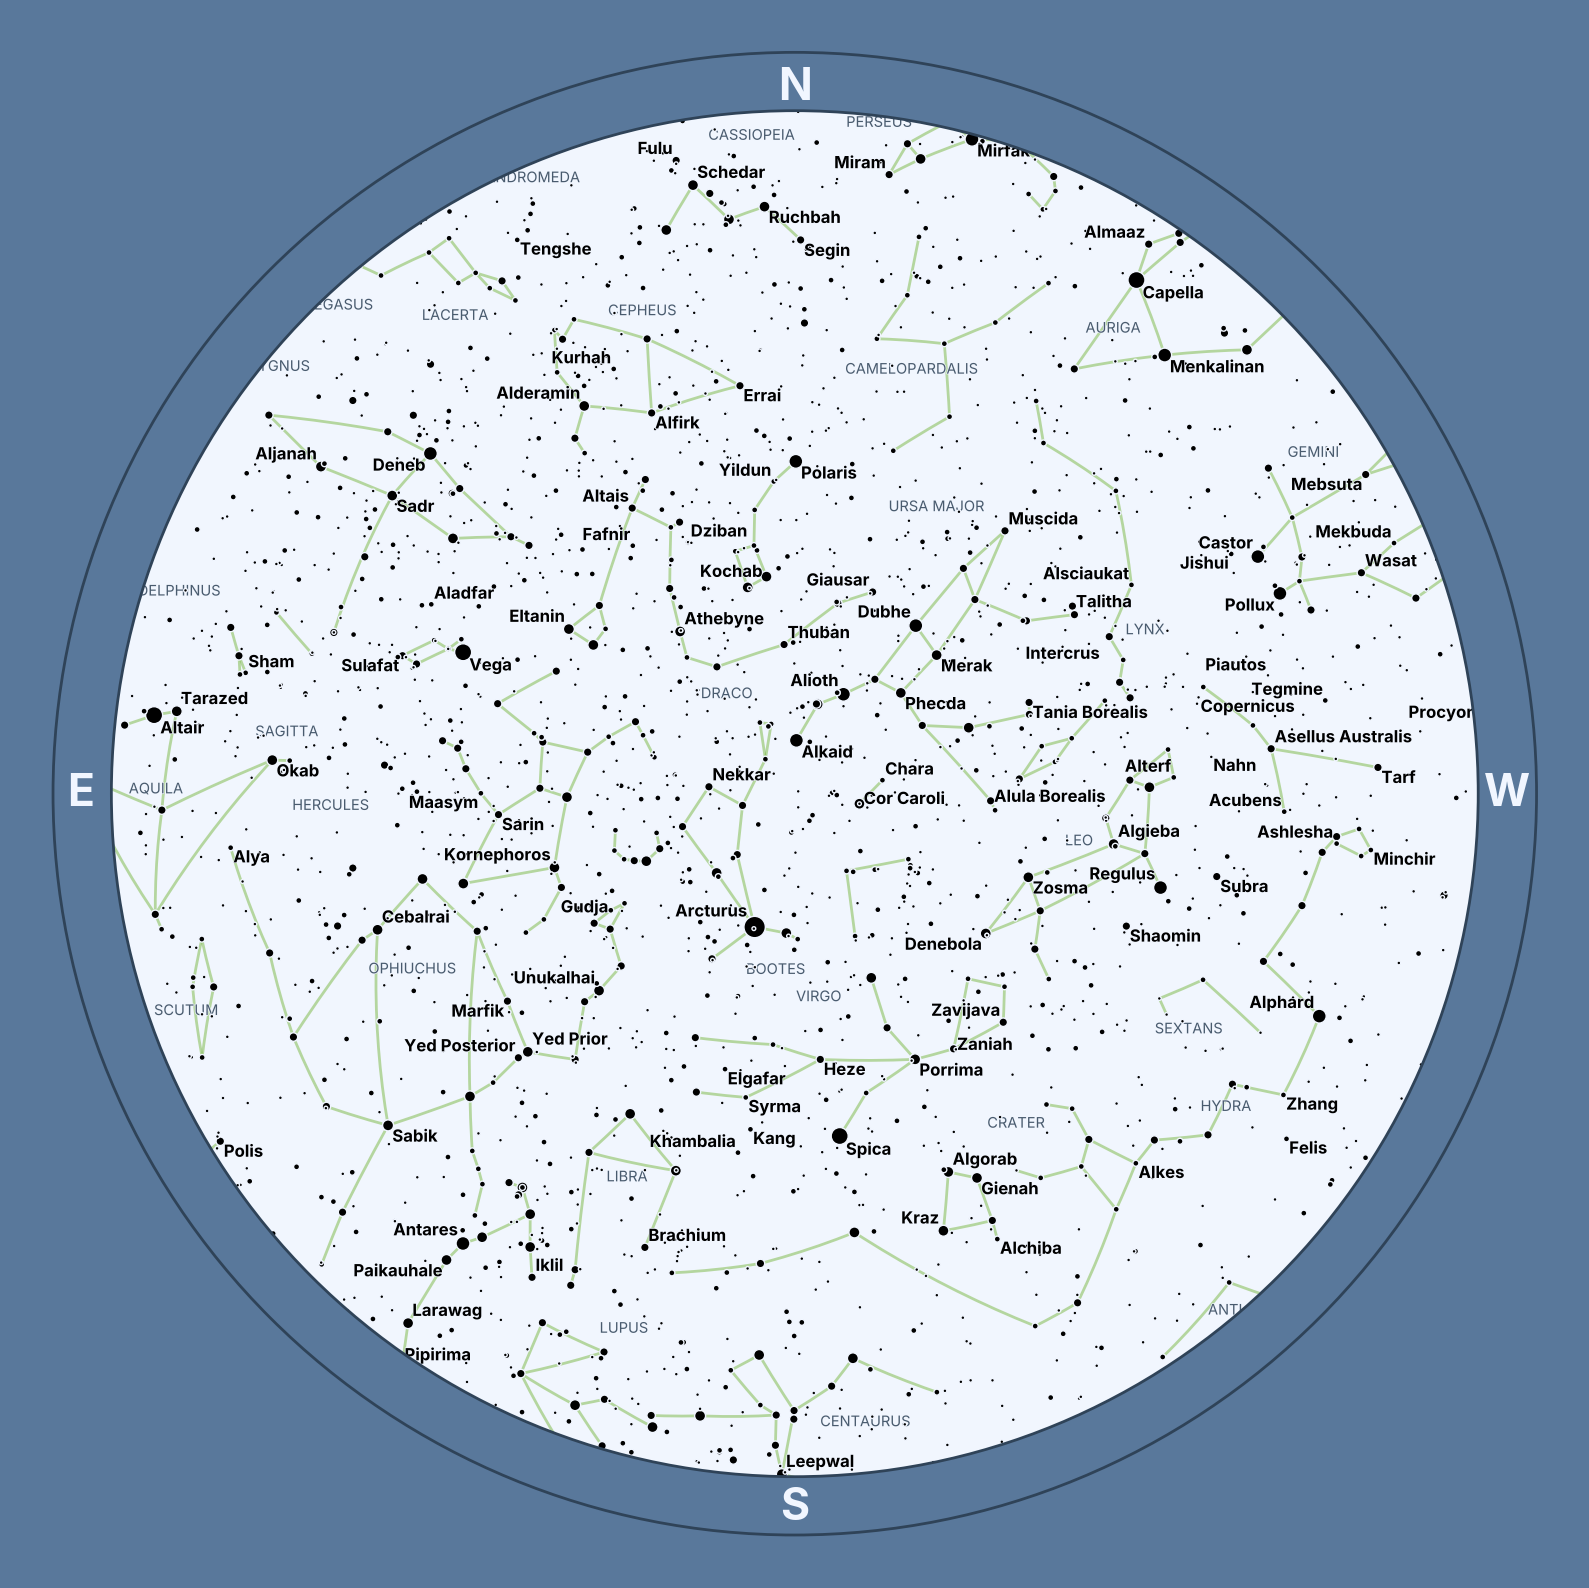

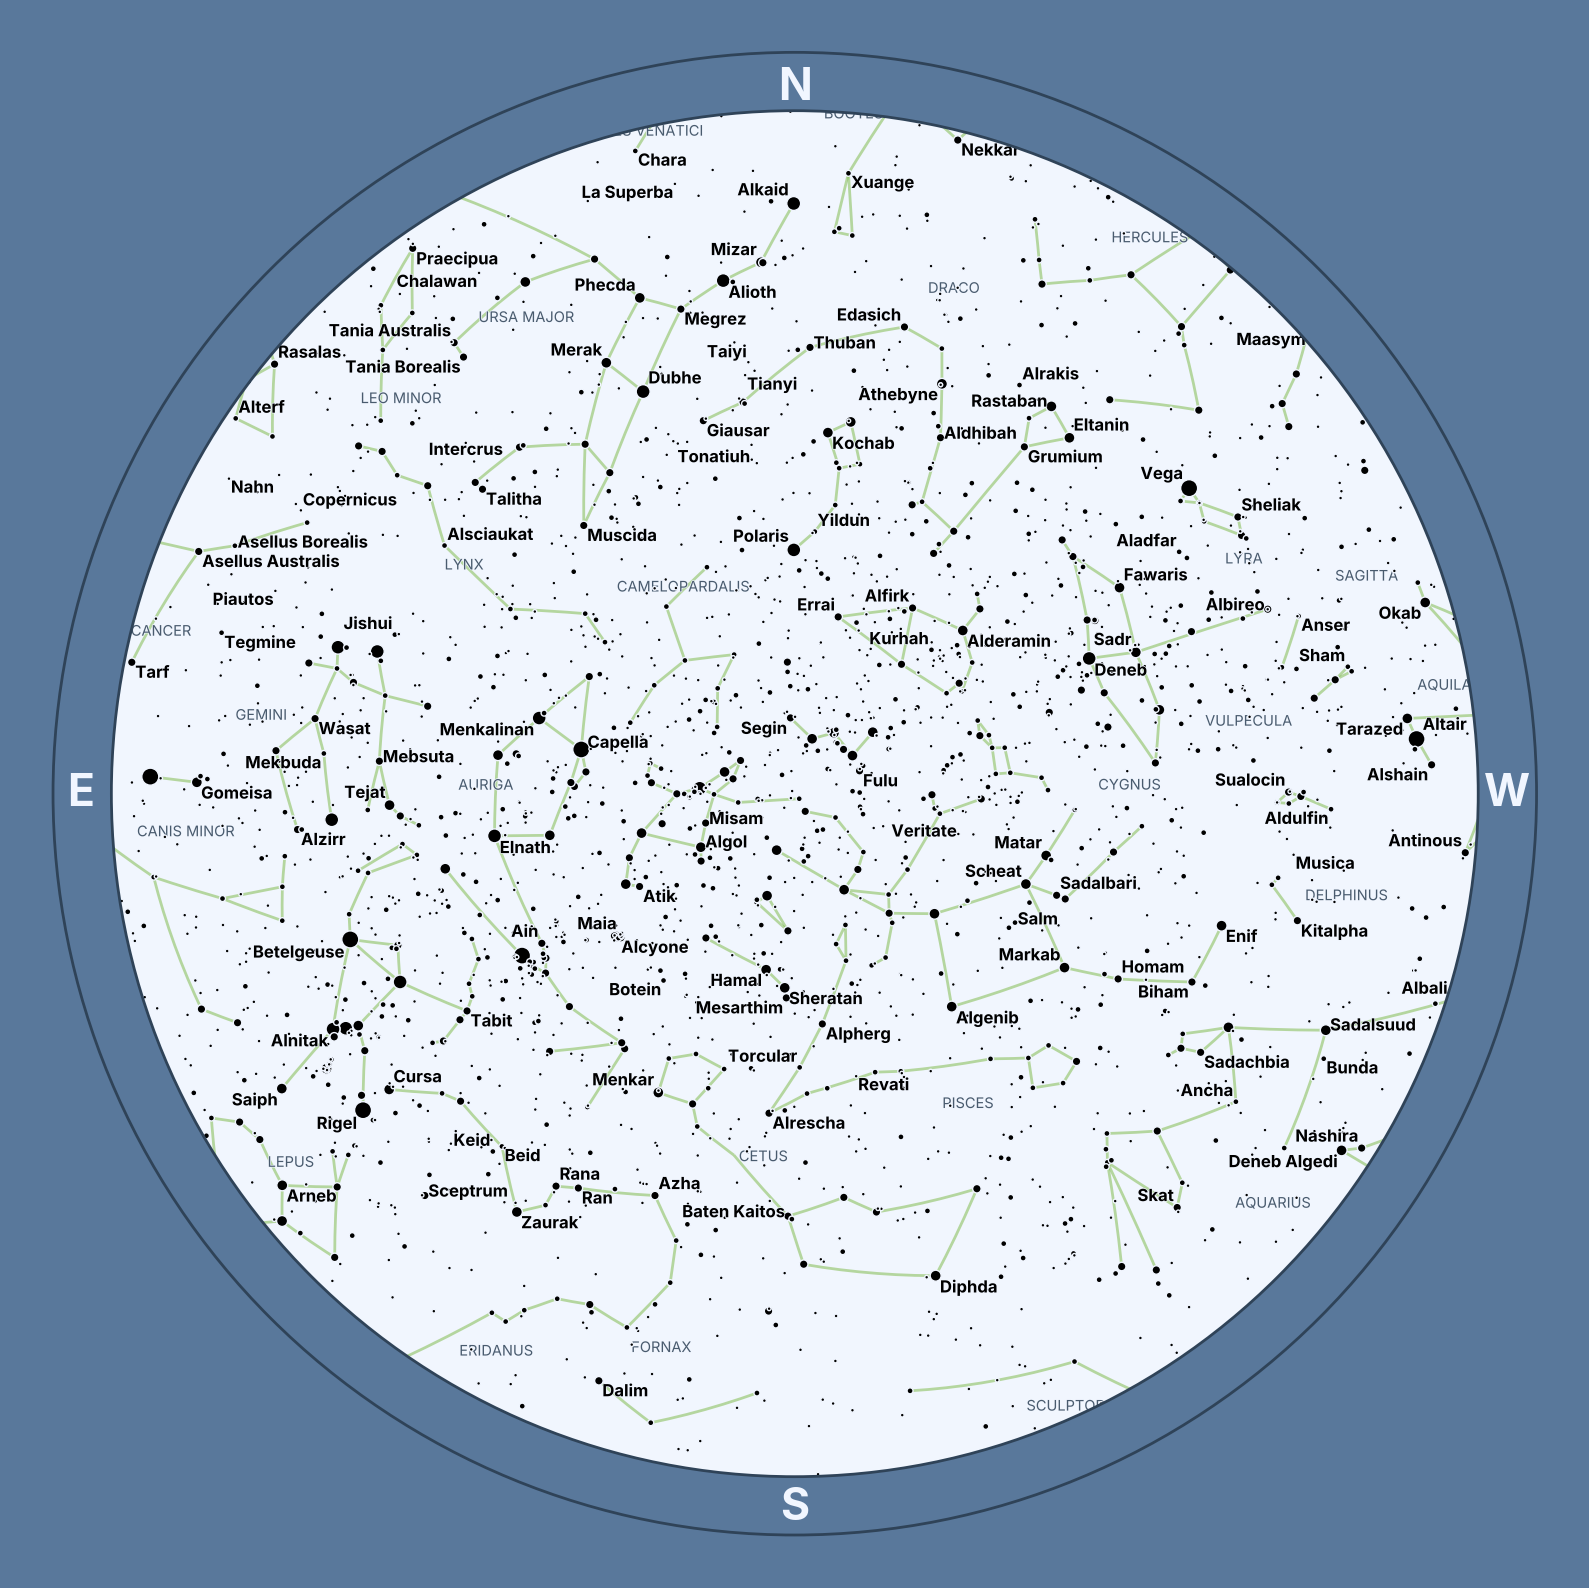

In [ ]:
for filename, city_name, lat, lon, tz_name, year, month, day, hour, minute in scenarios:
    tz = ZoneInfo(tz_name)
    dt = datetime(year, month, day, hour, minute, 0, tzinfo=tz)

    observer = Observer(
        dt=dt,
        lat=lat,
        lon=lon,
    )

    p = ZenithPlot(
        observer=observer,
        resolution=2048,
        autoscale=True,
        style=styles.PlotStyle().extend(
            styles.extensions.BLUE_MEDIUM,
        ),
    )

    p.stars(where=[_.magnitude < 6])
    p.constellations()
    p.constellation_labels()
    p.horizon()

    out_name = f"{filename}.png"
    p.export(out_name)
    print(f"Done: {city_name} → {out_name}")


In [ ]:
from PIL import Image, ImageDraw, ImageFont

def label_image(input_path, output_path, title, subtitle, watermark):
    img = Image.open(input_path).convert("RGBA")
    width, height = img.size

    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    # --- Title bar ---
    bar_height = int(height * 0.12)
    draw.rectangle([(0, 0), (width, bar_height)], fill=(0, 0, 0, 160))

    try:
        title_font = ImageFont.truetype("DejaVuSans-Bold.ttf", int(bar_height * 0.40))
        subtitle_font = ImageFont.truetype("DejaVuSans.ttf", int(bar_height * 0.28))
        watermark_font = ImageFont.truetype("DejaVuSans.ttf", int(height * 0.03))
    except:
        title_font = subtitle_font = watermark_font = ImageFont.load_default()

    # --- Title text ---
    title_bbox = draw.textbbox((0, 0), title, font=title_font)
    title_w = title_bbox[2] - title_bbox[0]
    title_h = title_bbox[3] - title_bbox[1]
    title_x = (width - title_w) // 2
    title_y = int(bar_height * 0.10)
    draw.text((title_x, title_y), title, fill="white", font=title_font)

    # --- Subtitle text ---
    subtitle_bbox = draw.textbbox((0, 0), subtitle, font=subtitle_font)
    subtitle_w = subtitle_bbox[2] - subtitle_bbox[0]
    subtitle_h = subtitle_bbox[3] - subtitle_bbox[1]
    subtitle_x = (width - subtitle_w) // 2
    subtitle_y = title_y + title_h + 5
    draw.text((subtitle_x, subtitle_y), subtitle, fill="white", font=subtitle_font)

    # --- Watermark (bottom-right) ---
    wm_bbox = draw.textbbox((0, 0), watermark, font=watermark_font)
    wm_w = wm_bbox[2] - wm_bbox[0]
    wm_h = wm_bbox[3] - wm_bbox[1]
    wm_x = width - wm_w - 20
    wm_y = height - wm_h - 20
    draw.text((wm_x, wm_y), watermark, fill="white", font=watermark_font)

    # Merge overlay
    labeled = Image.alpha_composite(img, overlay)
    labeled.convert("RGB").save(output_path)
    print(f"Labeled → {output_path}")


In [ ]:
labels = {
    "newyork_jan17_2026_21h.png": {
        "title": "New York • Jan 17 2026 • 9 PM EST",
        "subtitle": "Northern Hemisphere • Winter Sky",
    },
    "sydney_jan17_2026_21h.png": {
        "title": "Sydney • Jan 17 2026 • 9 PM AEDT",
        "subtitle": "Southern Hemisphere • Summer Sky",
    },
    "tokyo_jan17_2026_21h.png": {
        "title": "Tokyo • Jan 17 2026 • 9 PM JST",
        "subtitle": "Northern Hemisphere • Winter Sky",
    },
    "newyork_jun17_2026_21h.png": {
        "title": "New York • Jun 17 2026 • 9 PM EDT",
        "subtitle": "Northern Hemisphere • Summer Sky",
    },
    "london_jan17_2026_18h.png": {
        "title": "London • Jan 17 2026 • 6 PM GMT",
        "subtitle": "Northern Hemisphere • Winter Sky",
    },
}


In [ ]:

for infile, meta in labels.items():
    outfile = infile.replace(".png", "_labeled.png")
    label_image(
        infile,
        outfile,
        meta["title"],
        meta["subtitle"],
        watermark="Pallavi • Python + Starplot"
    )



Labeled → newyork_jan17_2026_21h_labeled.png
Labeled → sydney_jan17_2026_21h_labeled.png
Labeled → tokyo_jan17_2026_21h_labeled.png
Labeled → newyork_jun17_2026_21h_labeled.png
Labeled → london_jan17_2026_18h_labeled.png
